In [1]:
import os, glob
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nugraph as ng

torch.set_float32_matmul_precision("medium")

DATA_PATH = "/home/apaudel/NuGraph/scripts/merged1_Aug6_40k_pmtpmt_g4lepdir_with_vpred_nexusonly"
RUN_NAME = "merged1_Aug20_40k_g4lepdir_tpc_pds_semantic_vertex_direction_axisloss_fixedvpred_nexusfeat_pmtpmt_ep45_bs32_in8_sp5"

ckpts = glob.glob(f"/home/apaudel/NuGraph/logs/{RUN_NAME}/**/*.ckpt", recursive=True)
assert ckpts, f"No checkpoint found for {RUN_NAME}"
CKPT = max(ckpts, key=os.path.getmtime)

print("DATA_PATH =", DATA_PATH)
print("RUN_NAME  =", RUN_NAME)
print("CKPT      =", CKPT)

raw = torch.load(CKPT, map_location="cpu")
hp = raw.get("hyper_parameters", {})
print("\nCheckpoint hparams:")
for k in [
    "semantic_head", "vertex_head", "direction_head", "event_head",
    "sp_features", "use_optical", "use_pmt_pmt"
]:
    print(f"{k:16s} =", hp.get(k, "MISSING"))

Data = ng.data.H5DataModule
Model = ng.models.NuGraph3

nudata = Data(
    DATA_PATH,
    batch_size=32,
    num_workers=0,
    model=Model,
    shuffle="random",
    featext3d=True,
)

model = Model.load_from_checkpoint(CKPT)
model.eval()

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("\nDataset lengths:")
print("train =", len(nudata.train_dataset))
print("val   =", len(nudata.val_dataset))
print("test  =", len(nudata.test_dataset))

print("\nModel sanity:")
print("use_optical =", model.use_optical)
print("optical PMT-PMT active =", model.optical_net.use_pmt_pmt if hasattr(model, "optical_net") else None)
print("encoder.sp_net is None =", model.encoder.sp_net is None)

DATA_PATH = /home/apaudel/NuGraph/scripts/merged1_Aug6_40k_pmtpmt_g4lepdir_with_vpred_nexusonly
RUN_NAME  = merged1_Aug20_40k_g4lepdir_tpc_pds_semantic_vertex_direction_axisloss_fixedvpred_nexusfeat_pmtpmt_ep45_bs32_in8_sp5
CKPT      = /home/apaudel/NuGraph/logs/merged1_Aug20_40k_g4lepdir_tpc_pds_semantic_vertex_direction_axisloss_fixedvpred_nexusfeat_pmtpmt_ep45_bs32_in8_sp5/version_0/checkpoints/epoch=44-step=42300.ckpt

Checkpoint hparams:
semantic_head    = True
vertex_head      = True
direction_head   = True
event_head       = False
sp_features      = 5
use_optical      = True
use_pmt_pmt      = True

Dataset lengths:
train = 30080
val   = 1672
test  = 1672

Model sanity:
use_optical = True
optical PMT-PMT active = True
encoder.sp_net is None = False


,N test,signed cos mean,signed cos median,signed angle mean deg,signed angle median deg,signed angle p68 deg,signed angle p90 deg,axis cos mean,axis cos median,axis angle mean deg,axis angle median deg,axis angle p68 deg,axis angle p90 deg,frac axis angle < 10 deg,frac axis angle < 20 deg,frac axis angle < 30 deg,frac signed angle < 30 deg,fixed v_pred median err cm,model v median err cm
0,1672,0.1476,0.3064,78.764603,72.158096,112.085197,152.433502,0.6625,0.75,43.6703,41.4109,56.299301,79.231903,0.0682,0.1998,0.3541,0.2356,5.4797,185.149002


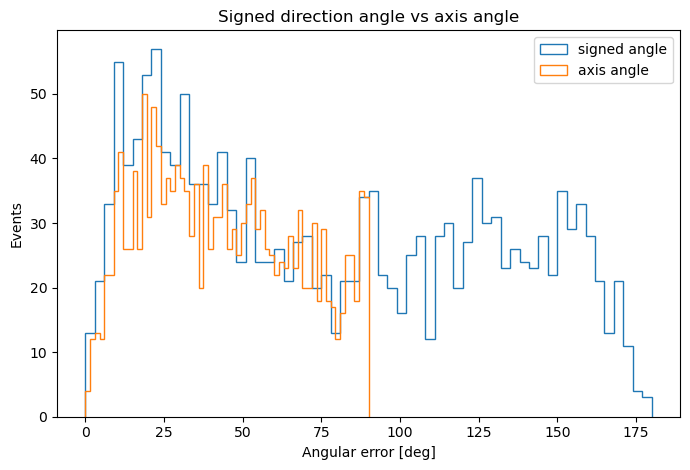

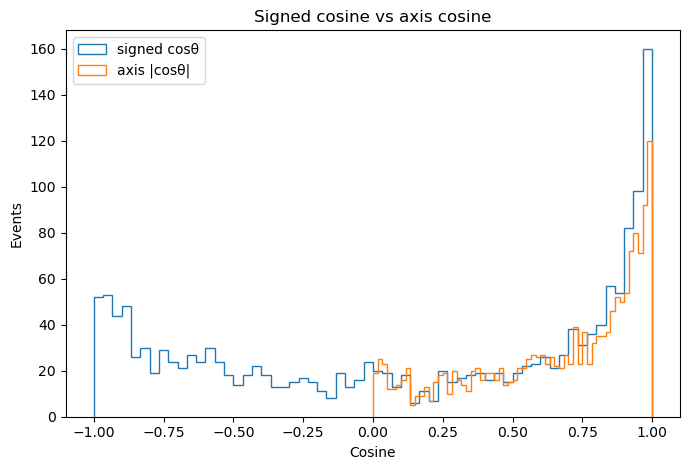

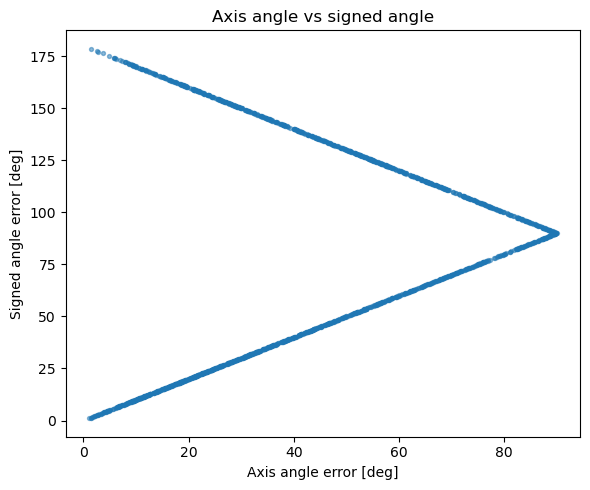

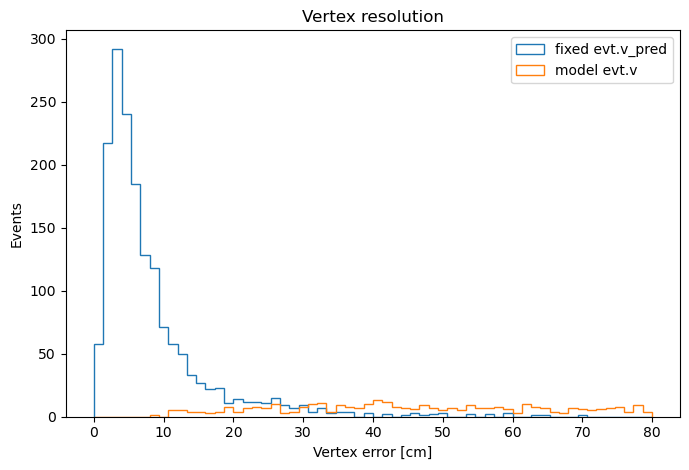

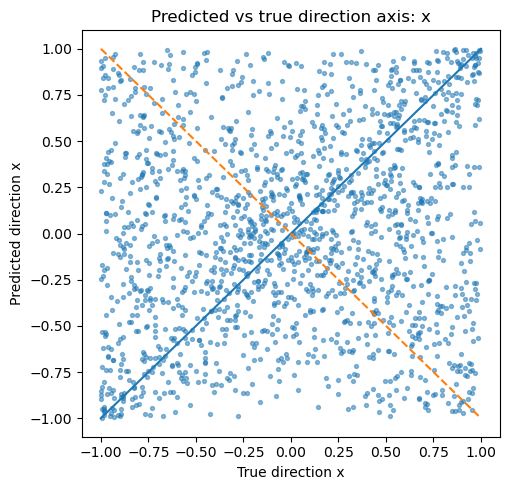

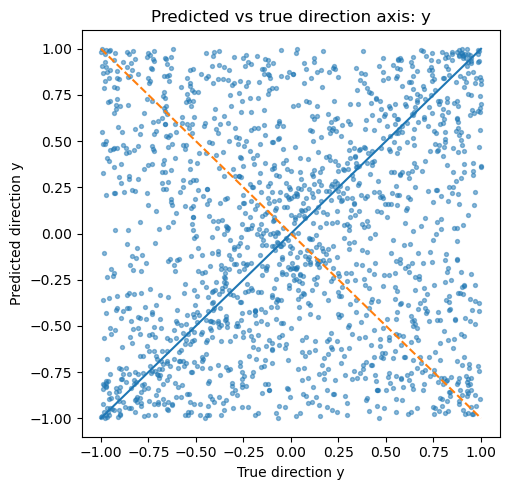

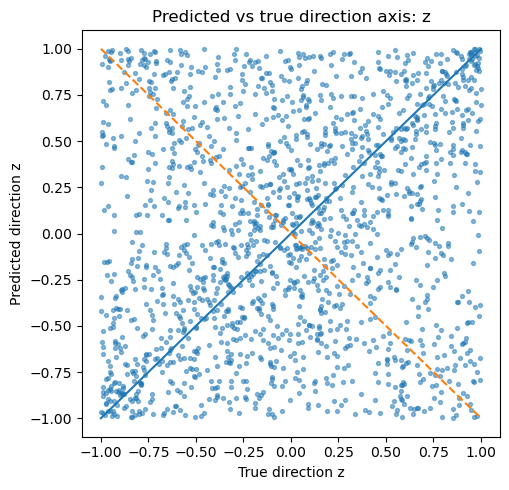

In [2]:
rows = []

with torch.no_grad():
    for batch in nudata.test_dataloader():
        batch = batch.to(device)

        # This fills batch["evt"].v and batch["evt"].d
        model(batch, "test")

        evt = batch["evt"]

        true_d = evt.y_dir.detach().float().cpu().numpy()
        pred_d = evt.d.detach().float().cpu().numpy()

        true_v = evt.y_vtx.detach().float().cpu().numpy()
        fixed_vpred = evt.v_pred.detach().float().cpu().numpy()
        model_v = evt.v.detach().float().cpu().numpy()

        rows.append((true_d, pred_d, true_v, fixed_vpred, model_v))

true_d = np.concatenate([r[0] for r in rows], axis=0)
pred_d = np.concatenate([r[1] for r in rows], axis=0)
true_v = np.concatenate([r[2] for r in rows], axis=0)
fixed_vpred = np.concatenate([r[3] for r in rows], axis=0)
model_v = np.concatenate([r[4] for r in rows], axis=0)

def unit(x):
    n = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.clip(n, 1.0e-12, None)

true_u = unit(true_d)
pred_u = unit(pred_d)

cos_signed = np.sum(true_u * pred_u, axis=1)
cos_signed = np.clip(cos_signed, -1.0, 1.0)

cos_axis = np.abs(cos_signed)

angle_signed_deg = np.degrees(np.arccos(cos_signed))
angle_axis_deg = np.degrees(np.arccos(cos_axis))

fixed_vtx_err = np.linalg.norm(fixed_vpred - true_v, axis=1)
model_vtx_err = np.linalg.norm(model_v - true_v, axis=1)

summary = {
    "N test": len(cos_signed),

    "signed cos mean": np.mean(cos_signed),
    "signed cos median": np.median(cos_signed),
    "signed angle mean deg": np.mean(angle_signed_deg),
    "signed angle median deg": np.median(angle_signed_deg),
    "signed angle p68 deg": np.percentile(angle_signed_deg, 68),
    "signed angle p90 deg": np.percentile(angle_signed_deg, 90),

    "axis cos mean": np.mean(cos_axis),
    "axis cos median": np.median(cos_axis),
    "axis angle mean deg": np.mean(angle_axis_deg),
    "axis angle median deg": np.median(angle_axis_deg),
    "axis angle p68 deg": np.percentile(angle_axis_deg, 68),
    "axis angle p90 deg": np.percentile(angle_axis_deg, 90),

    "frac axis angle < 10 deg": np.mean(angle_axis_deg < 10),
    "frac axis angle < 20 deg": np.mean(angle_axis_deg < 20),
    "frac axis angle < 30 deg": np.mean(angle_axis_deg < 30),
    "frac signed angle < 30 deg": np.mean(angle_signed_deg < 30),

    "fixed v_pred median err cm": np.median(fixed_vtx_err),
    "model v median err cm": np.median(model_vtx_err),
}

display(pd.DataFrame([summary]).round(4))

plt.figure(figsize=(7, 4.8))
plt.hist(angle_signed_deg, bins=60, range=(0, 180), histtype="step", label="signed angle")
plt.hist(angle_axis_deg, bins=60, range=(0, 90), histtype="step", label="axis angle")
plt.xlabel("Angular error [deg]")
plt.ylabel("Events")
plt.title("Signed direction angle vs axis angle")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.8))
plt.hist(cos_signed, bins=60, range=(-1, 1), histtype="step", label="signed cosθ")
plt.hist(cos_axis, bins=60, range=(0, 1), histtype="step", label="axis |cosθ|")
plt.xlabel("Cosine")
plt.ylabel("Events")
plt.title("Signed cosine vs axis cosine")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(angle_axis_deg, angle_signed_deg, s=8, alpha=0.5)
plt.xlabel("Axis angle error [deg]")
plt.ylabel("Signed angle error [deg]")
plt.title("Axis angle vs signed angle")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.8))
plt.hist(fixed_vtx_err, bins=60, range=(0, 80), histtype="step", label="fixed evt.v_pred")
plt.hist(model_vtx_err, bins=60, range=(0, 80), histtype="step", label="model evt.v")
plt.xlabel("Vertex error [cm]")
plt.ylabel("Events")
plt.title("Vertex resolution")
plt.legend()
plt.tight_layout()
plt.show()

for coord, label in [(0, "x"), (1, "y"), (2, "z")]:
    plt.figure(figsize=(5.2, 5.0))
    plt.scatter(true_u[:, coord], pred_u[:, coord], s=8, alpha=0.5)
    plt.plot([-1, 1], [-1, 1])
    plt.plot([-1, 1], [1, -1], linestyle="--")
    plt.xlabel(f"True direction {label}")
    plt.ylabel(f"Predicted direction {label}")
    plt.title(f"Predicted vs true direction axis: {label}")
    plt.tight_layout()
    plt.show()